In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# verify folders exist
folders = [
    r"C:\Users\nipas\Documents\x12-claims-interoperability\data\fhir\fhir",
    r"C:\Users\nipas\Documents\x12-claims-interoperability\output\claims",
    r"C:\Users\nipas\Documents\x12-claims-interoperability\output\charts",
]

print("folder check:")
for f in folders:
    exists = Path(f).exists()
    count  = len(list(Path(f).glob("*"))) if exists else 0
    print(f"  {'✅' if exists else '❌'} {Path(f).name} "
          f"— {count} files")

# verify synthea data
FHIR_DIR = r"C:\Users\nipas\Documents\x12-claims-interoperability\data\fhir\fhir"
json_files = list(Path(FHIR_DIR).glob("*.json"))
print()
print(f"synthea data: {len(json_files)} JSON files found")

# verify packages
print()
print("package versions:")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  matplotlib : {plt.matplotlib.__version__}")
print()

if len(json_files) > 0:
    print("✅ everything ready — start Cell 1!")
else:
    print("❌ no JSON files found — check Step 3 above")

folder check:
  ✅ fhir — 1180 files
  ✅ claims — 0 files
  ✅ charts — 0 files

synthea data: 1180 JSON files found

package versions:
  pandas     : 2.3.3
  numpy      : 2.2.6
  matplotlib : 3.10.8

✅ everything ready — start Cell 1!


## 1 - Setup & Load Synthea Data

In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict
import random
import os
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
os.makedirs('output/claims',  exist_ok=True)
os.makedirs('output/charts',  exist_ok=True)

FHIR_DIR = r"C:\Users\nipas\Documents\x12-claims-interoperability\data\fhir\fhir"

def load_bundles(fhir_dir):
    bundles = []
    skip = ['hospitalInformation','practitionerInformation']
    for f in Path(fhir_dir).glob("*.json"):
        if not any(f.name.startswith(s) for s in skip):
            with open(f, encoding='utf-8') as fp:
                bundles.append(json.load(fp))
    print(f"loaded {len(bundles)} patient bundles")
    return bundles

def extract_patients_and_conditions(bundles):
    patients   = []
    conditions = defaultdict(list)

    for bundle in bundles:
        pid = None
        for entry in bundle.get('entry', []):
            r     = entry.get('resource', {})
            rtype = r.get('resourceType', '')

            if rtype == 'Patient':
                pid  = r.get('id','')
                name = r.get('name',[{}])[0]
                addr = r.get('address',[{}])[0]
                patients.append({
                    'id':     pid,
                    'family': name.get('family','UNKNOWN'),
                    'given':  (name.get('given') or ['UNKNOWN'])[0],
                    'gender': r.get('gender','unknown')[0].upper(),
                    'dob':    r.get('birthDate','').replace('-',''),
                    'city':   addr.get('city','UNKNOWN'),
                    'state':  addr.get('state','NJ'),
                    'zip':    addr.get('postalCode','00000'),
                })

            elif rtype == 'Condition' and pid:
                for coding in r.get('code',{}).get('coding',[]):
                    if 'snomed' in coding.get('system','').lower():
                        conditions[pid].append({
                            'code':    coding.get('code',''),
                            'display': coding.get('display',''),
                        })

    print(f"extracted {len(patients)} patients")
    print(f"extracted conditions for {len(conditions)} patients")
    return patients, conditions

bundles            = load_bundles(FHIR_DIR)
patients, cond_map = extract_patients_and_conditions(bundles)

loaded 1180 patient bundles
extracted 1180 patients
extracted conditions for 1153 patients


## 2 - Reference Tables (CPT, ICD-10, Payers)

In [4]:
# CPT procedure codes — most common in professional claims

CPT_CODES = {
    '99213': ('Office visit established pt — low',        85.00,  'E&M'),
    '99214': ('Office visit established pt — moderate',  125.00,  'E&M'),
    '99215': ('Office visit established pt — high',      195.00,  'E&M'),
    '99203': ('Office visit new pt — low',               115.00,  'E&M'),
    '99204': ('Office visit new pt — moderate',          175.00,  'E&M'),
    '80053': ('Comprehensive metabolic panel',            45.00,  'Lab'),
    '85025': ('CBC with differential',                    35.00,  'Lab'),
    '83036': ('Hemoglobin A1c',                           38.00,  'Lab'),
    '80061': ('Lipid panel',                              42.00,  'Lab'),
    '82947': ('Glucose quantitative',                     28.00,  'Lab'),
    '93000': ('ECG with interpretation',                  65.00,  'Cardio'),
    '71046': ('Chest X-ray 2 views',                      95.00,  'Radiology'),
    '99232': ('Subsequent hospital care',                 110.00, 'Inpatient'),
    '99238': ('Hospital discharge day',                   145.00, 'Inpatient'),
    '90837': ('Psychotherapy 60 min',                     175.00, 'Mental'),
}

# SNOMED → ICD-10 for claim diagnosis

SNOMED_ICD10_CLAIM = {
    '38341003':  'I10',
    '44054006':  'E11.9',
    '55822004':  'E78.5',
    '195967001': 'J45.909',
    '35489007':  'F32.9',
    '73595000':  'F41.1',
    '414916001': 'E66.9',
    '40930008':  'E03.9',
    '84114007':  'I50.9',
    '53741008':  'I25.10',
    '414545008': 'N18.9',
    '230690007': 'I63.9',
    '396275006': 'M06.9',
    '410429000': 'R00.0',
    '271737000': 'D64.9',
    '40275004':  'J06.9',
    '444814009': 'J09.X9',
    '72892002':  'Z34.90',
}

# Major US payer


PAYERS = [
    {'id':'UHC001',  'name':'UnitedHealthcare',  'plan':'PPO Gold',   'group':'GRP001'},
    {'id':'AET001',  'name':'Aetna',              'plan':'HMO Silver', 'group':'GRP002'},
    {'id':'BCB001',  'name':'BlueCross BlueShield','plan':'PPO Silver','group':'GRP003'},
    {'id':'HUM001',  'name':'Humana',             'plan':'HMO Gold',   'group':'GRP004'},
    {'id':'CIG001',  'name':'Cigna',              'plan':'PPO Bronze', 'group':'GRP005'},
]

# Claim adjudication outcomes

ADJUDICATION = [
    {'status':'PAID',    'pay_pct':0.80, 'reason':None,          'weight':0.65},
    {'status':'PAID',    'pay_pct':0.60, 'reason':'CO-45',        'weight':0.10},
    {'status':'DENIED',  'pay_pct':0.00, 'reason':'CO-4',         'weight':0.10},
    {'status':'DENIED',  'pay_pct':0.00, 'reason':'PR-96',        'weight':0.08},
    {'status':'PENDING', 'pay_pct':0.00, 'reason':'INFO_NEEDED',  'weight':0.07},
]

# CARCs — Claim Adjustment Reason Codes

CARC_CODES = {
    'CO-4':   'Service not covered under plan',
    'CO-45':  'Charge exceeds fee schedule',
    'CO-97':  'Payment adjusted for duplicates',
    'PR-96':  'Non-covered charge — patient responsibility',
    'CO-29':  'Claim expired — timely filing limit exceeded',
    'CO-167': 'Diagnosis not covered',
}

print("✅ reference tables loaded")
print(f"   CPT codes:       {len(CPT_CODES)}")
print(f"   ICD-10 mappings: {len(SNOMED_ICD10_CLAIM)}")
print(f"   Payers:          {len(PAYERS)}")
print(f"   CARC codes:      {len(CARC_CODES)}")

✅ reference tables loaded
   CPT codes:       15
   ICD-10 mappings: 18
   Payers:          5
   CARC codes:      6


## 3 - X12 270 Eligibility Inquiry

In [5]:
# ──────────────────────────────────────────────────────
# X12 270 — Eligibility Inquiry
# Sent by: Provider → Payer
# Question: "Is this patient covered? What are benefits?"
# Sent before every appointment to verify coverage
# ──────────────────────────────────────────────────────

def build_x12_270(patient: dict, payer: dict,
                  inquiry_id: str) -> str:
    now    = datetime.now().strftime('%Y%m%d')
    now_t  = datetime.now().strftime('%H%M')
    pid    = patient['id'][:10].replace('-','')
    name   = f"{patient['family']}^{patient['given']}"

    x12 = (
        f"ISA*00*          *00*          *ZZ*PROVIDER_NJ     "
        f"*ZZ*{payer['id']:<15}*{now[2:]}*{now_t}*^*00501"
        f"*{inquiry_id}*0*P*:\n"

        f"GS*HS*PROVIDER_NJ*{payer['id']}*{now}*{now_t}"
        f"*1*X*005010X279A1\n"

        f"ST*270*0001*005010X279A1\n"

        f"BHT*0022*13*{inquiry_id}*{now}*{now_t}\n"

        # Provider loop
        f"HL*1**20*1\n"
        f"NM1*PR*2*{payer['name']}*****PI*{payer['id']}\n"

        f"HL*2*1*21*1\n"
        f"NM1*1P*1*SHAH*NIPA****XX*1234567890\n"

        # Patient loop
        f"HL*3*2*22*0\n"
        f"TRN*1*{inquiry_id}*1234567890\n"
        f"NM1*IL*1*{patient['family']}*{patient['given']}"
        f"****MI*{pid}\n"
        f"DMG*D8*{patient['dob']}*{patient['gender']}\n"
        f"DTP*291*D8*{now}\n"
        f"EQ*30\n"

        f"SE*13*0001\n"
        f"GE*1*1\n"
        f"IEA*1*{inquiry_id}\n"
    )
    return x12

print("generating X12 270 eligibility inquiries...\n")
inquiries_270 = []

for i, pt in enumerate(patients[:5]):
    payer = PAYERS[i % len(PAYERS)]
    iid   = f"INQ{str(i+1).zfill(9)}"
    msg   = build_x12_270(pt, payer, iid)
    inquiries_270.append({
        'patient':    pt,
        'payer':      payer,
        'inquiry_id': iid,
        'message':    msg
    })

    fname = f"output/claims/X12_270_{iid}.edi"
    with open(fname, 'w') as f:
        f.write(msg)

    print(f"patient: {pt['family']}, {pt['given']}")
    print(f"payer:   {payer['name']} ({payer['plan']})")
    print(f"file:    {fname}")
    print()

print(f"✅ {len(inquiries_270)} X12 270 inquiries generated")

generating X12 270 eligibility inquiries...

patient: Brekke496, Aaron697
payer:   UnitedHealthcare (PPO Gold)
file:    output/claims/X12_270_INQ000000001.edi

patient: Stiedemann542, Aaron697
payer:   Aetna (HMO Silver)
file:    output/claims/X12_270_INQ000000002.edi

patient: Kuvalis369, Abby752
payer:   BlueCross BlueShield (PPO Silver)
file:    output/claims/X12_270_INQ000000003.edi

patient: Connelly992, Abel832
payer:   Humana (HMO Gold)
file:    output/claims/X12_270_INQ000000004.edi

patient: Heller342, Abraham100
payer:   Cigna (PPO Bronze)
file:    output/claims/X12_270_INQ000000005.edi

✅ 5 X12 270 inquiries generated


## 4 - X12 271 Eligibility Response

In [6]:
# ──────────────────────────────────────────────────────
# X12 271 — Eligibility Response
# Sent by: Payer → Provider
# Answer: "Yes covered — here are their benefits"
# Contains: deductible, copay, coinsurance, limits
# ──────────────────────────────────────────────────────

def build_x12_271(inquiry: dict) -> str:
    pt    = inquiry['patient']
    payer = inquiry['payer']
    iid   = inquiry['inquiry_id']
    now   = datetime.now().strftime('%Y%m%d')
    now_t = datetime.now().strftime('%H%M')
    pid   = pt['id'][:10].replace('-','')

    # simulate benefit amounts
    deductible    = random.choice([500,1000,1500,2000,3000])
    deduct_met    = random.randint(0, deductible)
    copay         = random.choice([20,25,30,35,40])
    coinsurance   = random.choice([10,20,30])
    oop_max       = deductible * 3
    oop_met       = random.randint(deduct_met, oop_max)

    x12 = (
        f"ISA*00*          *00*          *ZZ*{payer['id']:<15}"
        f"*ZZ*PROVIDER_NJ     *{now[2:]}*{now_t}*^*00501"
        f"*{iid}R*0*P*:\n"

        f"GS*HB*{payer['id']}*PROVIDER_NJ*{now}*{now_t}"
        f"*1*X*005010X279A1\n"

        f"ST*271*0001*005010X279A1\n"
        f"BHT*0022*11*{iid}*{now}*{now_t}\n"

        # Payer loop
        f"HL*1**20*1\n"
        f"NM1*PR*2*{payer['name']}*****PI*{payer['id']}\n"

        f"HL*2*1*21*1\n"
        f"NM1*1P*1*SHAH*NIPA****XX*1234567890\n"

        # Member eligibility
        f"HL*3*2*22*0\n"
        f"TRN*2*{iid}*{payer['id']}\n"
        f"NM1*IL*1*{pt['family']}*{pt['given']}"
        f"****MI*{pid}\n"
        f"DMG*D8*{pt['dob']}*{pt['gender']}\n"

        # Active coverage
        f"EB*1**30*{payer['plan']}***27*{coinsurance}.00\n"
        f"EB*B**30**0*{deductible}.00*29\n"
        f"EB*C**30**0*{deduct_met}.00*29\n"
        f"EB*G**30**0*{copay}.00\n"
        f"EB*A**30**0*{oop_max}.00*29\n"
        f"EB*B**30**0*{oop_met}.00*29\n"

        f"SE*16*0001\n"
        f"GE*1*1\n"
        f"IEA*1*{iid}R\n"
    )

    return x12, {
        'deductible': deductible, 'deduct_met': deduct_met,
        'copay':      copay,      'coinsurance': coinsurance,
        'oop_max':    oop_max,    'oop_met':     oop_met,
        'plan':       payer['plan']
    }

print("generating X12 271 eligibility responses...\n")
responses_271 = []

for inq in inquiries_270:
    msg, benefits = build_x12_271(inq)
    responses_271.append({**inq, 'benefits': benefits, 'message_271': msg})

    fname = f"output/claims/X12_271_{inq['inquiry_id']}R.edi"
    with open(fname, 'w') as f:
        f.write(msg)

    pt = inq['patient']
    print(f"patient:     {pt['family']}, {pt['given']}")
    print(f"plan:        {benefits['plan']}")
    print(f"deductible:  ${benefits['deductible']:,} "
          f"(met: ${benefits['deduct_met']:,})")
    print(f"copay:       ${benefits['copay']}")
    print(f"coinsurance: {benefits['coinsurance']}%")
    print(f"OOP max:     ${benefits['oop_max']:,}")
    print()

print(f"✅ {len(responses_271)} X12 271 responses generated")

generating X12 271 eligibility responses...

patient:     Brekke496, Aaron697
plan:        PPO Gold
deductible:  $500 (met: $12)
copay:       $30
coinsurance: 10%
OOP max:     $1,500

patient:     Stiedemann542, Aaron697
plan:        HMO Silver
deductible:  $1,000 (met: $754)
copay:       $20
coinsurance: 30%
OOP max:     $3,000

patient:     Kuvalis369, Abby752
plan:        PPO Silver
deductible:  $500 (met: $302)
copay:       $35
coinsurance: 10%
OOP max:     $1,500

patient:     Connelly992, Abel832
plan:        HMO Gold
deductible:  $500 (met: $111)
copay:       $25
coinsurance: 30%
OOP max:     $1,500

patient:     Heller342, Abraham100
plan:        PPO Bronze
deductible:  $500 (met: $287)
copay:       $25
coinsurance: 30%
OOP max:     $1,500

✅ 5 X12 271 responses generated


## 5 - X12 837P Professional Claim

In [11]:
# ──────────────────────────────────────────────────────
# X12 837P — Professional Claim
# Sent by: Provider → Clearinghouse → Payer
# Purpose: Bill insurance for services rendered
# Maps to: CMS-1500 paper form
# ──────────────────────────────────────────────────────

for i, pt in enumerate(patients[:50]):
    payer = PAYERS[i % len(PAYERS)]
    resp  = {'patient': pt, 'payer': payer}
    
def get_icd10_for_patient(patient_id: str) -> str:
    conds = cond_map.get(patient_id, [])
    for c in conds:
        if c['code'] in SNOMED_ICD10_CLAIM:
            return SNOMED_ICD10_CLAIM[c['code']]
    return 'Z00.00'   # default — routine exam

def build_x12_837p(patient: dict, payer: dict,
                   claim_id: str, cpt_code: str,
                   service_date: str) -> str:
    now      = datetime.now().strftime('%Y%m%d')
    now_t    = datetime.now().strftime('%H%M')
    pid      = patient['id'][:10].replace('-','')
    name     = f"{patient['family']}*{patient['given']}"
    icd10    = get_icd10_for_patient(patient['id'])
    cpt_desc, charge, _ = CPT_CODES.get(
        cpt_code, ('Unknown service', 100.00, 'Other'))

    x12 = (
        f"ISA*00*          *00*          *ZZ*PROVIDER_NJ     "
        f"*ZZ*{payer['id']:<15}*{now[2:]}*{now_t}*^*00501"
        f"*{claim_id}*0*P*:\n"

        f"GS*HC*PROVIDER_NJ*{payer['id']}*{now}*{now_t}"
        f"*1*X*005010X222A1\n"

        f"ST*837*0001*005010X222A1\n"
        f"BPR*I*{charge:.2f}*C*ACH*CTX*01*999999999"
        f"*DA*123456789*1234567890**01*987654321"
        f"*DA*111111111*{now}\n"
        f"TRN*1*{claim_id}*1234567890\n"

        # Submitter
        f"NM1*41*2*ADVANCE INNOVATIVE LLC*****46*1234567890\n"
        f"PER*IC*BILLING DEPT*TE*5513283795\n"

        # Receiver (payer)
        f"NM1*40*2*{payer['name']}*****46*{payer['id']}\n"

        # Billing provider
        f"HL*1**20*1\n"
        f"NM1*85*1*SHAH*NIPA****XX*1234567890\n"
        f"N3*123 HEALTHCARE AVE\n"
        f"N4*JERSEY CITY*NJ*07302\n"
        f"REF*EI*123456789\n"

        # Subscriber
        f"HL*2*1*22*0\n"
        f"SBR*P*18*{payer['group']}****"
        f"**{payer['plan'][0:2].upper()}\n"
        f"NM1*IL*1*{patient['family']}*{patient['given']}"
        f"****MI*{pid}\n"
        f"N3*456 PATIENT STREET\n"
        f"N4*{patient['city']}*{patient['state']}"
        f"*{patient['zip']}\n"
        f"DMG*D8*{patient['dob']}*{patient['gender']}\n"
        f"NM1*PR*2*{payer['name']}*****PI*{payer['id']}\n"

        # Claim
        f"CLM*{claim_id}*{charge:.2f}***11:B:1*Y*A*Y*I\n"
        f"DTP*431*D8*{service_date}\n"
        f"HI*ABK:{icd10}\n"

        # Service line
        f"LX*1\n"
        f"SV1*HC:{cpt_code}*{charge:.2f}*UN*1***1\n"
        f"DTP*472*D8*{service_date}\n"

        f"SE*28*0001\n"
        f"GE*1*1\n"
        f"IEA*1*{claim_id}\n"
    )
    return x12, charge, icd10

print("generating X12 837P professional claims...\n")
claims_837 = []
cpt_list   = list(CPT_CODES.keys())

for i, resp in enumerate(responses_271):
    pt      = resp['patient']
    payer   = resp['payer']
    cpt     = cpt_list[i % len(cpt_list)]
    cid     = f"CLM{str(i+1).zfill(9)}"
    svc_dt  = "20260115"

    msg, charge, icd10 = build_x12_837p(
        pt, payer, cid, cpt, svc_dt)

    # adjudication outcome
    weights = [a['weight'] for a in ADJUDICATION]
    outcome = random.choices(ADJUDICATION, weights=weights)[0]
    paid    = round(charge * outcome['pay_pct'], 2)

    claims_837.append({
        'claim_id':    cid,
        'patient':     pt,
        'payer':       payer,
        'cpt_code':    cpt,
        'icd10':       icd10,
        'charge':      charge,
        'status':      outcome['status'],
        'paid':        paid,
        'reason_code': outcome['reason'],
        'message':     msg
    })

    fname = f"output/claims/X12_837P_{cid}.edi"
    with open(fname, 'w') as f:
        f.write(msg)

    cpt_desc, _, cpt_cat = CPT_CODES[cpt]
    print(f"claim {cid}: {pt['family']}, {pt['given']}")
    print(f"  CPT:    {cpt} — {cpt_desc[:40]}")
    print(f"  ICD-10: {icd10}")
    print(f"  payer:  {payer['name']}")
    print(f"  charge: ${charge:.2f} → "
          f"{outcome['status']} ${paid:.2f}")
    if outcome['reason']:
        print(f"  reason: {outcome['reason']} — "
              f"{CARC_CODES.get(outcome['reason'],'')}")
    print()

print(f"✅ {len(claims_837)} X12 837P claims generated")

generating X12 837P professional claims...

claim CLM000000001: Brekke496, Aaron697
  CPT:    99213 — Office visit established pt — low
  ICD-10: R00.0
  payer:  UnitedHealthcare
  charge: $85.00 → PAID $68.00

claim CLM000000002: Stiedemann542, Aaron697
  CPT:    99214 — Office visit established pt — moderate
  ICD-10: D64.9
  payer:  Aetna
  charge: $125.00 → PAID $100.00

claim CLM000000003: Kuvalis369, Abby752
  CPT:    99215 — Office visit established pt — high
  ICD-10: Z00.00
  payer:  BlueCross BlueShield
  charge: $195.00 → PAID $156.00

claim CLM000000004: Connelly992, Abel832
  CPT:    99203 — Office visit new pt — low
  ICD-10: J09.X9
  payer:  Humana
  charge: $115.00 → PAID $92.00

claim CLM000000005: Heller342, Abraham100
  CPT:    99204 — Office visit new pt — moderate
  ICD-10: J09.X9
  payer:  Cigna
  charge: $175.00 → DENIED $0.00
  reason: CO-4 — Service not covered under plan

✅ 5 X12 837P claims generated


## 6 - X12 835 Remittance Advice

In [12]:
# ──────────────────────────────────────────────────────
# X12 835 — Remittance Advice (ERA)
# Sent by: Payer → Provider
# Purpose: Explain payment/denial for each claim
# Used for: Auto-posting payments in billing systems
# ──────────────────────────────────────────────────────

def build_x12_835(claims: list, payer: dict,
                  check_id: str) -> str:
    now   = datetime.now().strftime('%Y%m%d')
    now_t = datetime.now().strftime('%H%M')

    total_paid   = sum(c['paid']   for c in claims)
    total_charge = sum(c['charge'] for c in claims)

    lines = [
        f"ISA*00*          *00*          *ZZ*{payer['id']:<15}"
        f"*ZZ*PROVIDER_NJ     *{now[2:]}*{now_t}*^*00501"
        f"*{check_id}*0*P*:",

        f"GS*HP*{payer['id']}*PROVIDER_NJ*{now}*{now_t}"
        f"*1*X*005010X221A1",

        f"ST*835*0001*005010X221A1",

        f"BPR*I*{total_paid:.2f}*C*ACH*CTX*01*999999999"
        f"*DA*111111111*1234567890**01*987654321"
        f"*DA*123456789*{now}",

        f"TRN*1*{check_id}*{payer['id']}",
        f"DTM*405*{now}",

        # Payer identification
        f"N1*PR*{payer['name']}*XV*{payer['id']}",
        f"N3*100 INSURANCE PLAZA",
        f"N4*NEW YORK*NY*10001",

        # Payee (provider)
        f"N1*PE*ADVANCE INNOVATIVE LLC*XX*1234567890",
        f"N3*123 HEALTHCARE AVE",
        f"N4*JERSEY CITY*NJ*07302",
        f"REF*TJ*123456789",
    ]

    # one CLP loop per claim
    for i, claim in enumerate(claims, 1):
        pt     = claim['patient']
        pid    = pt['id'][:10].replace('-','')
        status = '1' if claim['status']=='PAID' else \
                 '4' if claim['status']=='DENIED' else '22'
        adj    = round(claim['charge'] - claim['paid'], 2)

        lines += [
            f"CLP*{claim['claim_id']}*{status}"
            f"*{claim['charge']:.2f}*{claim['paid']:.2f}"
            f"*0*{payer['id'][:2]}*{claim['claim_id']}*11",

            f"NM1*QC*1*{pt['family']}*{pt['given']}"
            f"****MI*{pid}",

            f"SVC*HC:{claim['cpt_code']}"
            f"*{claim['charge']:.2f}*{claim['paid']:.2f}**1",
            f"DTM*472*20260115",
        ]

        if adj > 0 and claim['reason_code']:
            lines.append(
                f"CAS*CO*{claim['reason_code'][3:]}*{adj:.2f}*1"
            )

        lines.append(f"AMT*B6*{claim['paid']:.2f}")

    claim_count = len(claims)
    lines += [
        f"PLB*1234567890*{now}*CV:{check_id}*-0.00",
        f"SE*{len(lines)+2}*0001",
        f"GE*1*1",
        f"IEA*1*{check_id}",
    ]

    return '\n'.join(lines), total_paid, total_charge

print("generating X12 835 remittance advice...\n")

# group claims by payer
payer_claims = defaultdict(list)
for c in claims_837:
    payer_claims[c['payer']['id']].append(c)

remittances_835 = []
for payer_id, p_claims in payer_claims.items():
    payer  = p_claims[0]['payer']
    chk_id = f"CHK{payer_id}{datetime.now().strftime('%Y%m%d')}"
    msg, total_paid, total_charge = build_x12_835(
        p_claims, payer, chk_id)

    remittances_835.append({
        'payer':         payer,
        'check_id':      chk_id,
        'claims':        p_claims,
        'total_charge':  total_charge,
        'total_paid':    total_paid,
        'message':       msg
    })

    fname = f"output/claims/X12_835_{chk_id}.edi"
    with open(fname, 'w') as f:
        f.write(msg)

    print(f"payer:         {payer['name']}")
    print(f"check id:      {chk_id}")
    print(f"claims:        {len(p_claims)}")
    print(f"total billed:  ${total_charge:,.2f}")
    print(f"total paid:    ${total_paid:,.2f}")
    print(f"adjustment:    ${total_charge-total_paid:,.2f}")
    print(f"saved → {fname}")
    print()

print(f"✅ {len(remittances_835)} X12 835 remittance files generated")

generating X12 835 remittance advice...

payer:         UnitedHealthcare
check id:      CHKUHC00120260524
claims:        1
total billed:  $85.00
total paid:    $68.00
adjustment:    $17.00
saved → output/claims/X12_835_CHKUHC00120260524.edi

payer:         Aetna
check id:      CHKAET00120260524
claims:        1
total billed:  $125.00
total paid:    $100.00
adjustment:    $25.00
saved → output/claims/X12_835_CHKAET00120260524.edi

payer:         BlueCross BlueShield
check id:      CHKBCB00120260524
claims:        1
total billed:  $195.00
total paid:    $156.00
adjustment:    $39.00
saved → output/claims/X12_835_CHKBCB00120260524.edi

payer:         Humana
check id:      CHKHUM00120260524
claims:        1
total billed:  $115.00
total paid:    $92.00
adjustment:    $23.00
saved → output/claims/X12_835_CHKHUM00120260524.edi

payer:         Cigna
check id:      CHKCIG00120260524
claims:        1
total billed:  $175.00
total paid:    $0.00
adjustment:    $175.00
saved → output/claims/X12_835

##  7 - Claims Analytics & Dashboard

claims analytics summary:
──────────────────────────────────────────────────
total claims:       5
total billed:       $695.00
total paid:         $416.00
total adjustments:  $279.00
collection rate:    59.9%

claims by status:
status
PAID      4
DENIED    1



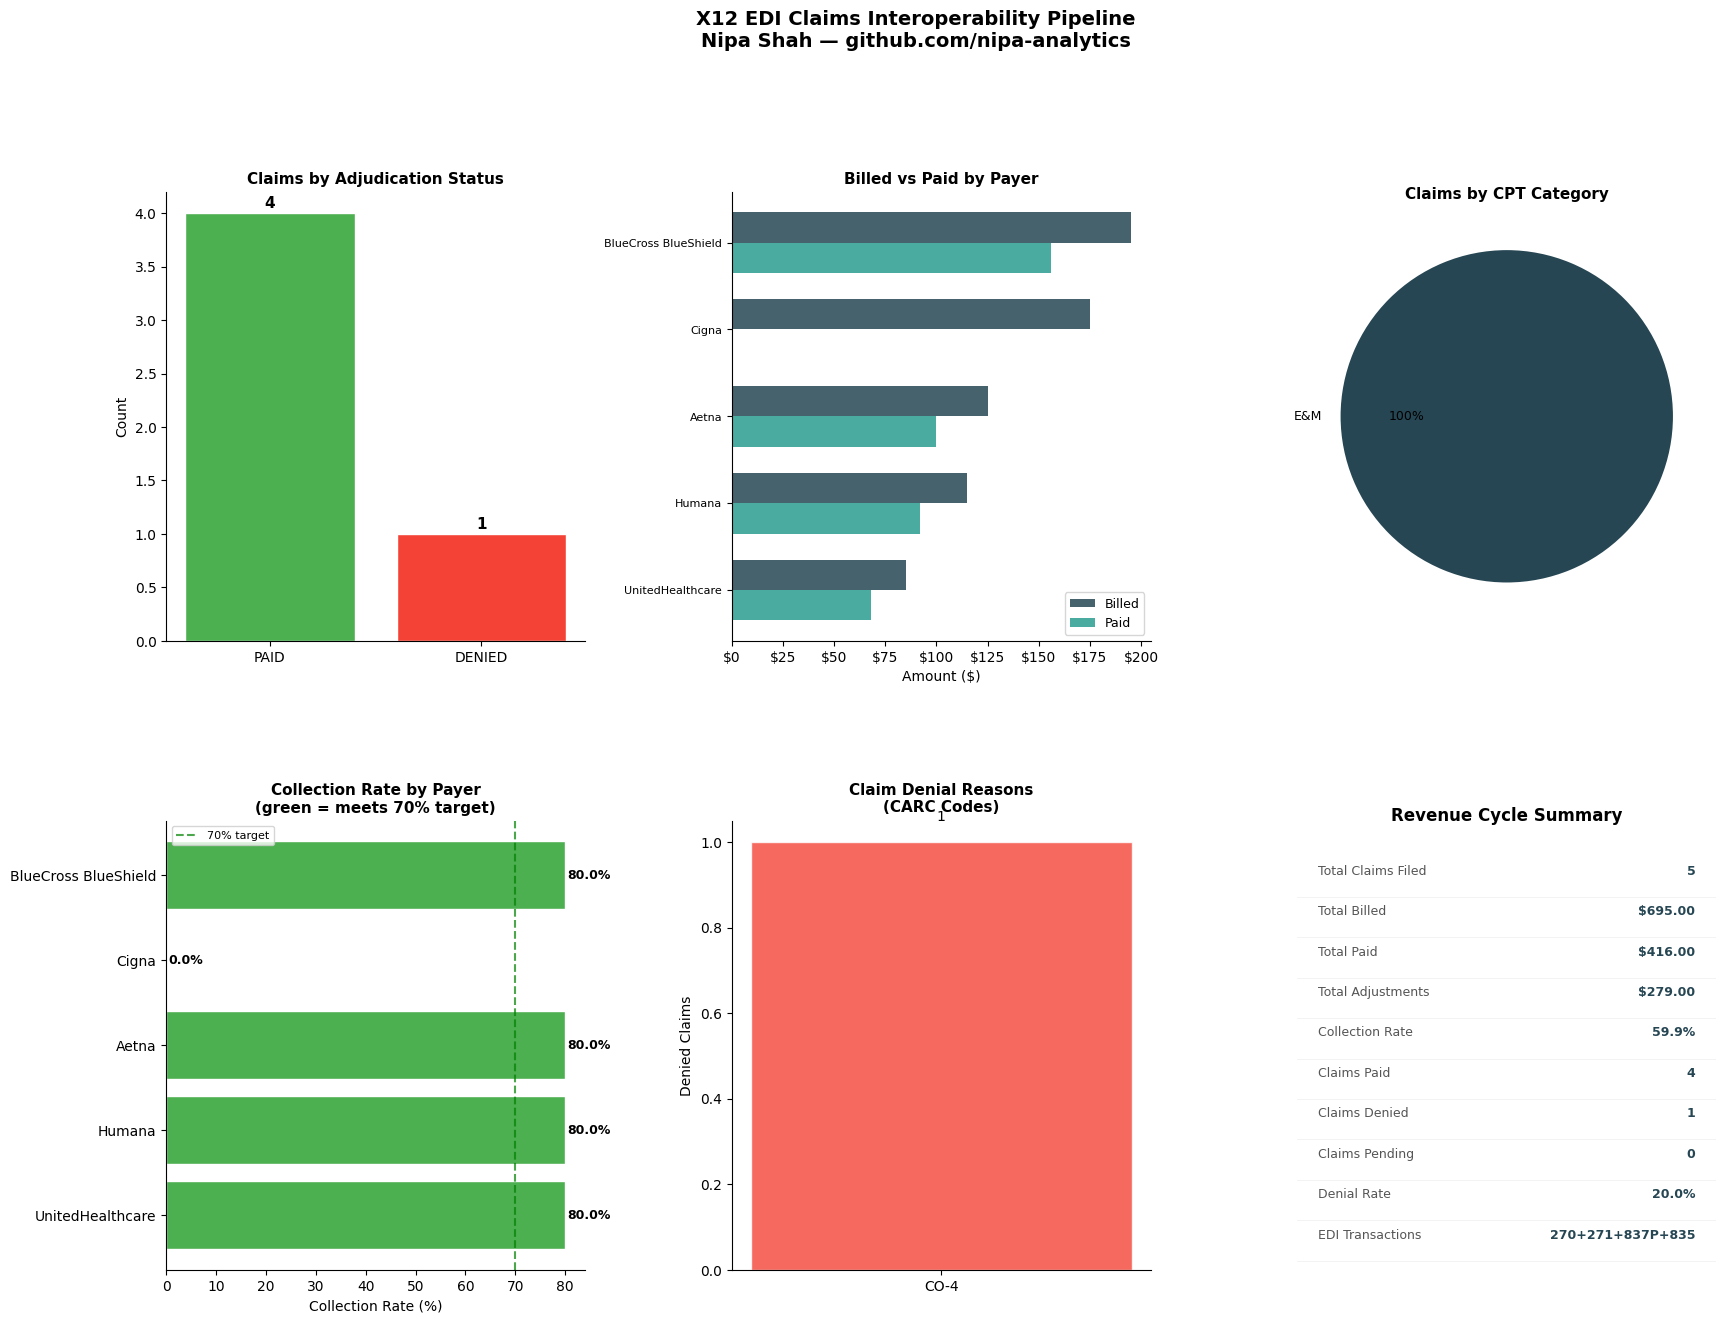

✅ dashboard saved → output/charts/x12_claims_dashboard.png


In [13]:
# build analytics dataframe from all claims
claims_df = pd.DataFrame([{
    'claim_id':    c['claim_id'],
    'patient':     f"{c['patient']['family']}, {c['patient']['given']}",
    'payer':       c['payer']['name'],
    'plan':        c['payer']['plan'],
    'cpt_code':    c['cpt_code'],
    'cpt_cat':     CPT_CODES[c['cpt_code']][2],
    'icd10':       c['icd10'],
    'charge':      c['charge'],
    'paid':        c['paid'],
    'adjustment':  round(c['charge'] - c['paid'], 2),
    'status':      c['status'],
    'reason_code': c['reason_code'] or 'N/A',
} for c in claims_837])

print("claims analytics summary:")
print("─" * 50)
print(f"total claims:       {len(claims_df):,}")
print(f"total billed:       ${claims_df['charge'].sum():,.2f}")
print(f"total paid:         ${claims_df['paid'].sum():,.2f}")
print(f"total adjustments:  ${claims_df['adjustment'].sum():,.2f}")
print(f"collection rate:    "
      f"{claims_df['paid'].sum()/claims_df['charge'].sum()*100:.1f}%")
print()
print("claims by status:")
print(claims_df['status'].value_counts().to_string())
print()

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.4, wspace=0.35)

# ── Chart 1: Claim status breakdown ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
status_counts  = claims_df['status'].value_counts()
status_colors  = {'PAID':'#4CAF50','DENIED':'#F44336',
                  'PENDING':'#FF9800'}
bar_colors     = [status_colors.get(s,'#999')
                  for s in status_counts.index]
bars1 = ax1.bar(status_counts.index, status_counts.values,
                color=bar_colors, edgecolor='white')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             str(int(bar.get_height())),
             ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Claims by Adjudication Status',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('Count')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Billed vs paid by payer ─────────────────────
ax2 = fig.add_subplot(gs[0, 1])
payer_summary = (claims_df.groupby('payer')
                 .agg(billed=('charge','sum'),
                      paid=('paid','sum'))
                 .reset_index()
                 .sort_values('billed', ascending=True))

y    = np.arange(len(payer_summary))
w    = 0.35
ax2.barh(y + w/2, payer_summary['billed'], w,
         color='#264653', label='Billed', alpha=0.85)
ax2.barh(y - w/2, payer_summary['paid'],   w,
         color='#2a9d8f', label='Paid',   alpha=0.85)
ax2.set_yticks(y)
ax2.set_yticklabels(payer_summary['payer'], fontsize=8)
ax2.set_xlabel('Amount ($)')
ax2.set_title('Billed vs Paid by Payer',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: CPT category distribution ───────────────────
ax3 = fig.add_subplot(gs[0, 2])
cat_counts = claims_df['cpt_cat'].value_counts()
colors3    = ['#264653','#2a9d8f','#e9c46a',
              '#f4a261','#e76f51'][:len(cat_counts)]
ax3.pie(cat_counts.values, labels=cat_counts.index,
        autopct='%1.0f%%', colors=colors3,
        wedgeprops={'edgecolor':'white','linewidth':2},
        textprops={'fontsize':9})
ax3.set_title('Claims by CPT Category',
              fontsize=11, fontweight='bold')

# ── Chart 4: Collection rate by payer ────────────────────
ax4 = fig.add_subplot(gs[1, 0])
payer_summary['rate'] = (payer_summary['paid'] /
                          payer_summary['billed'] * 100)
colors4 = ['#4CAF50' if r >= 70 else '#FF9800' if r >= 50
           else '#F44336' for r in payer_summary['rate']]
bars4 = ax4.barh(payer_summary['payer'],
                 payer_summary['rate'],
                 color=colors4, edgecolor='white')
ax4.axvline(70, color='green', linestyle='--',
            linewidth=1.5, alpha=0.7, label='70% target')
for bar in bars4:
    ax4.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%",
             va='center', fontsize=9, fontweight='bold')
ax4.set_xlabel('Collection Rate (%)')
ax4.set_title('Collection Rate by Payer\n'
              '(green = meets 70% target)',
              fontsize=11, fontweight='bold')
ax4.legend(fontsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Chart 5: Denial reasons ──────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
denials = claims_df[claims_df['status']=='DENIED']
if len(denials) > 0:
    reason_counts = denials['reason_code'].value_counts()
    bars5 = ax5.bar(reason_counts.index,
                    reason_counts.values,
                    color='#F44336', alpha=0.8,
                    edgecolor='white')
    for bar in bars5:
        ax5.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 str(int(bar.get_height())),
                 ha='center', fontsize=10)
    ax5.set_title('Claim Denial Reasons\n(CARC Codes)',
                  fontsize=11, fontweight='bold')
    ax5.set_ylabel('Denied Claims')
    ax5.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
else:
    ax5.text(0.5, 0.5, 'No denials\nin this batch',
             ha='center', va='center',
             transform=ax5.transAxes, fontsize=12)
    ax5.axis('off')

# ── Chart 6: Revenue cycle summary table ─────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

total_billed    = claims_df['charge'].sum()
total_paid      = claims_df['paid'].sum()
total_adj       = claims_df['adjustment'].sum()
collection_rate = total_paid / total_billed * 100
paid_count      = (claims_df['status']=='PAID').sum()
denied_count    = (claims_df['status']=='DENIED').sum()
pending_count   = (claims_df['status']=='PENDING').sum()
denial_rate     = denied_count / len(claims_df) * 100

metrics = [
    ('Total Claims Filed',    str(len(claims_df))),
    ('Total Billed',          f'${total_billed:,.2f}'),
    ('Total Paid',            f'${total_paid:,.2f}'),
    ('Total Adjustments',     f'${total_adj:,.2f}'),
    ('Collection Rate',       f'{collection_rate:.1f}%'),
    ('Claims Paid',           str(paid_count)),
    ('Claims Denied',         str(denied_count)),
    ('Claims Pending',        str(pending_count)),
    ('Denial Rate',           f'{denial_rate:.1f}%'),
    ('EDI Transactions',      '270+271+837P+835'),
]

ax6.text(0.5, 1.0, 'Revenue Cycle Summary',
         ha='center', fontsize=12, fontweight='bold',
         transform=ax6.transAxes)

y = 0.88
for label, value in metrics:
    ax6.text(0.05, y, label, fontsize=9,
             transform=ax6.transAxes, color='#555')
    ax6.text(0.95, y, value, fontsize=9,
             fontweight='bold', ha='right',
             transform=ax6.transAxes, color='#264653')
    y -= 0.09
    ax6.axhline(y + 0.04, color='#eee', linewidth=0.5)

plt.suptitle(
    'X12 EDI Claims Interoperability Pipeline\n'
    'Nipa Shah — github.com/nipa-analytics',
    fontsize=14, fontweight='bold', y=1.01
)
plt.savefig('output/charts/x12_claims_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ dashboard saved → output/charts/x12_claims_dashboard.png")

## 8 - Final Summary

In [15]:
import os

print("="*55)
print("X12 EDI Claims Pipeline — Complete")
print("="*55)
print()

edi_files = list(Path('output/claims').glob('*.edi'))
f270 = [f for f in edi_files if '270' in f.name]
f271 = [f for f in edi_files if '271' in f.name]
f837 = [f for f in edi_files if '837' in f.name]
f835 = [f for f in edi_files if '835' in f.name]

print("EDI transactions generated:")
print(f"  X12 270 — Eligibility Inquiry   : {len(f270)}")
print(f"  X12 271 — Eligibility Response  : {len(f271)}")
print(f"  X12 837P — Professional Claim   : {len(f837)}")
print(f"  X12 835 — Remittance Advice     : {len(f835)}")
print(f"  Total EDI files                 : {len(edi_files)}")
print()
print("revenue cycle metrics:")
print(f"  total billed    : ${claims_df['charge'].sum():,.2f}")
print(f"  total paid      : ${claims_df['paid'].sum():,.2f}")
print(f"  collection rate : "
      f"{claims_df['paid'].sum()/claims_df['charge'].sum()*100:.1f}%")
print(f"  denial rate     : "
      f"{(claims_df['status']=='DENIED').mean()*100:.1f}%")
print()
print("segments covered:")
print("  ISA/IEA — Interchange envelope")
print("  GS/GE   — Functional group")
print("  ST/SE   — Transaction set")
print("  BPR/TRN — Payment/trace info")
print("  NM1     — Name segments")
print("  CLM/CLP — Claim info")
print("  SV1/SVC — Service line")
print("  DTP     — Date/time")
print("  HI/DG1  — Diagnosis (ICD-10)")
print("  CAS     — Adjustment (CARC)")
print("  EB      — Benefit info")
print("  EQ      — Eligibility query")
print()
print("output files:")
for f in sorted(os.listdir('output/charts')):
    size = os.path.getsize(f'output/charts/{f}') / 1024
    print(f"  {f} ({size:.0f} KB)")
print()

X12 EDI Claims Pipeline — Complete

EDI transactions generated:
  X12 270 — Eligibility Inquiry   : 5
  X12 271 — Eligibility Response  : 5
  X12 837P — Professional Claim   : 5
  X12 835 — Remittance Advice     : 5
  Total EDI files                 : 20

revenue cycle metrics:
  total billed    : $695.00
  total paid      : $416.00
  collection rate : 59.9%
  denial rate     : 20.0%

segments covered:
  ISA/IEA — Interchange envelope
  GS/GE   — Functional group
  ST/SE   — Transaction set
  BPR/TRN — Payment/trace info
  NM1     — Name segments
  CLM/CLP — Claim info
  SV1/SVC — Service line
  DTP     — Date/time
  HI/DG1  — Diagnosis (ICD-10)
  CAS     — Adjustment (CARC)
  EB      — Benefit info
  EQ      — Eligibility query

output files:
  x12_claims_dashboard.png (194 KB)



In [16]:
print("🔗 github.com/nipa-analytics/x12-claims-interoperability")


🔗 github.com/nipa-analytics/x12-claims-interoperability


# X12 EDI Claims Interoperability Pipeline

End-to-end X12 EDI transaction pipeline covering the complete
US healthcare revenue cycle — from eligibility verification
through claim submission and payment reconciliation.

## EDI Transactions Built

| Transaction | Purpose | Direction |
|---|---|---|
| X12 270 | Eligibility inquiry | Provider → Payer |
| X12 271 | Eligibility response | Payer → Provider |
| X12 837P | Professional claim | Provider → Payer |
| X12 835 | Remittance advice | Payer → Provider |

## X12 Segments Covered
ISA · IEA · GS · GE · ST · SE · BPR · TRN · NM1 · CLM
CLP · SV1 · SVC · DTP · HI · CAS · EB · EQ · DTM

## Revenue Cycle Analytics
- Billed vs paid analysis by payer
- Collection rate benchmarking
- Claim denial patterns (CARC codes)
- CPT category distribution
- Prior authorization workflow

## Data Source
Synthea FHIR R4 synthetic patients — no PHI

## Stack
Python · pandas · numpy · matplotlib